# Predicting Vehicle Prices Using Regression Models

## **Objectives**  
The primary goal of this project is to develop a robust regression model to predict used car prices for a reseller based on various listed features and specifications. In addition to predicting prices, the project focuses on identifying feature importance and mitigating overfitting through the application of regularisation techniques.

There can be several business objectives for this, such as:

* **Price Prediction**: Model car prices based on features like mileage, fuel type, and performance.
* **Market Analysis**: Explore trends and preferences in the used car market, by type, region, or other metrics.
* **Feature Importance**: Identify the most important factors influencing car prices (e.g., fuel type, mileage, age).

### **Tasks Overview**
The data pipeline for this task involves the following steps:  
1. **Dataset Overview**   
2. **Data Preprocessing**
3. **Data Visualisation & Exploration**
4. **Model Building**
3. **Regularisation**

## **1 Data Understanding**

| **Variable** | **Description** |
--------|--------------|
| `make_model` | The brand and model of the vehicle (e.g., 'Audi A1'). |
| `body_type` | The body style of the vehicle, such as Sedan, Compact, or Station Wagon. |
| `price`  | The listed price of the car in currency. |
| `vat`  | Indicates the VAT status for the vehicle's price (e.g., VAT deductible, Price negotiable). |
| `km` | The total mileage (in kilometers) of the vehicle, indicating its usage. |
| `Type` | Condition of the vehicle, whether it's 'Used' or 'New'.|
| `Fuel` | Type of fuel the vehicle uses, such as 'Diesel', 'Benzine', etc. |
| `Gears` | The number of gears in the vehicle's transmission. |
| `Comfort_Convenience` | Comfort and convenience features, such as 'Air conditioning', 'Leather steering wheel', 'Cruise control', and more. |
| `Entertainment_Media` | Media features available in the vehicle, including 'Bluetooth', 'MP3', 'Radio', etc. |
| `Extras` | Additional features like 'Alloy wheels', 'Sport suspension', etc.|
| `Safety_Security` | Safety features like 'ABS', 'Airbags', 'Electronic stability control', 'Isofix', etc.  |
| `age` | Age of the car (calculated based on the model year). |
| `Previous_Owners`| The number of previous owners the car has had. |
| `hp_kW` | Engine power in kilowatts (kW), indicating the performance capacity of the engine.|
| `Inspection_new` | Indicates whether the car has recently undergone an inspection (1 for yes, 0 for no). |
| `Paint_Type`| The type of paint on the car, such as 'Metallic', 'Matte', etc. |
| `Upholstery_type` | The material used for the interior upholstery, such as 'Cloth', 'Leather', etc.|
| `Gearing_Type` | The type of transmission the car uses, either 'Automatic' or 'Manual'. |
| `Displacement_cc` | The engine displacement in cubic centimeters (cc), indicating the size of the engine.|
| `Weight_kg` | The total weight of the vehicle in kilograms.|
| `Drive_chain` | The type of drivetrain, indicating whether it's 'Front' or 'Rear' wheel drive. |
| `cons_comb`  | The combined fuel consumption in liters per 100 kilometers.|

### **1.1 Data Loading**

**Importing Necessary Libraries**

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline



#### **1.1.1**
Load the dataset

In [2]:
# Load the data
df = pd.read_csv('Car_Price_data.csv', index_col=0); df.head()


,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,Extras,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
make_model,,,,,,,,,,,,,,,,,,,,,
Audi A1,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...","Alloy wheels,Catalytic Converter,Voice Control",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
Audi A1,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...","Alloy wheels,Sport seats,Sport suspension,Voic...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
Audi A1,Sedans,14640,VAT deductible,83450.0,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer","Alloy wheels,Voice Control",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
Audi A1,Sedans,14500,VAT deductible,73000.0,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...","Alloy wheels,Sport seats,Voice Control",...,1.0,66.0,0,Metallic,Cloth,Automatic,1422.0,1195.0,front,3.8
Audi A1,Sedans,16790,VAT deductible,16200.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...","Alloy wheels,Sport package,Sport suspension,Vo...",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1135.0,front,4.1


## **2 Analysis and Feature Engineering** <font color =red> [35 marks] </font>



### **2.1 Preliminary Analysis and Frequency Distributions** <font color = red> [13 marks] </font>

#### **2.1.1** <font color =red> [1 marks] </font>
Check and fix missing values.

In [3]:
# Find the proportion of missing values in each column and handle if found
df.isnull().sum()

,0
body_type,0
price,0
vat,0
km,0
Type,0
Fuel,0
Gears,0
Comfort_Convenience,0
Entertainment_Media,0
Extras,0


**From the features, identify the target feature and numerical and categorical predictors. Select the numerical and categorical features carefully as they will be used in analysis.**

#### **2.1.2** <font color =red> [3 marks] </font>
Identify numerical predictors and plot their frequency distributions.

Numerical Predictors Identified: ['km', 'Gears', 'age', 'Previous_Owners', 'hp_kW', 'Inspection_new', 'Displacement_cc', 'Weight_kg', 'cons_comb']



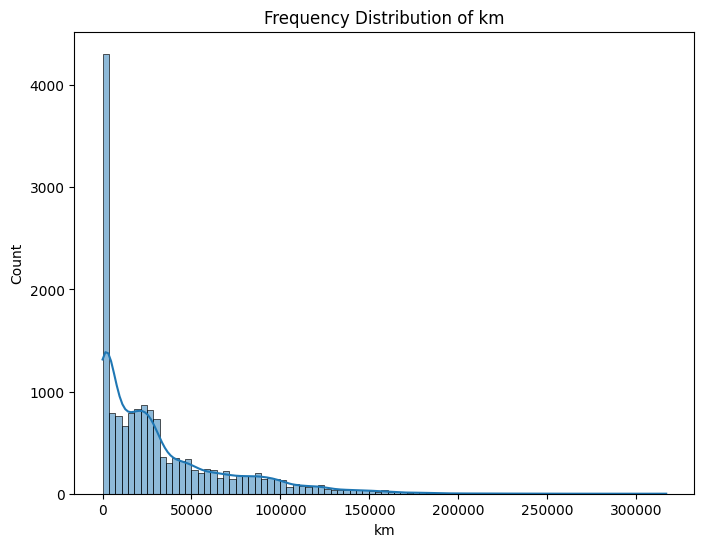

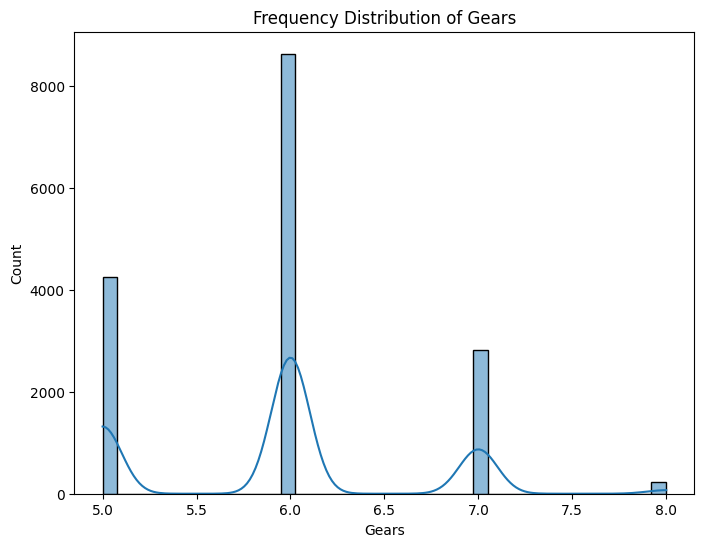

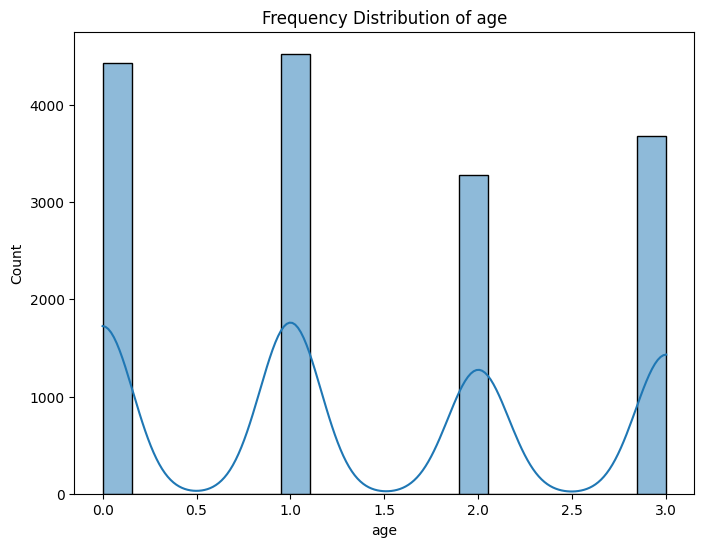

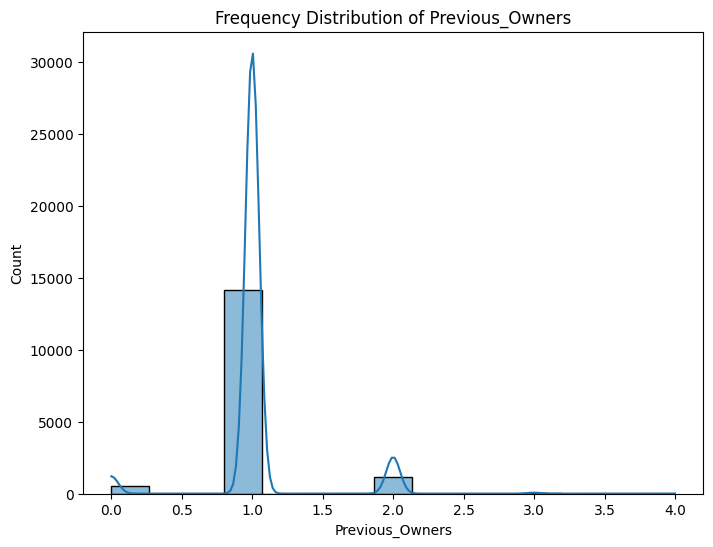

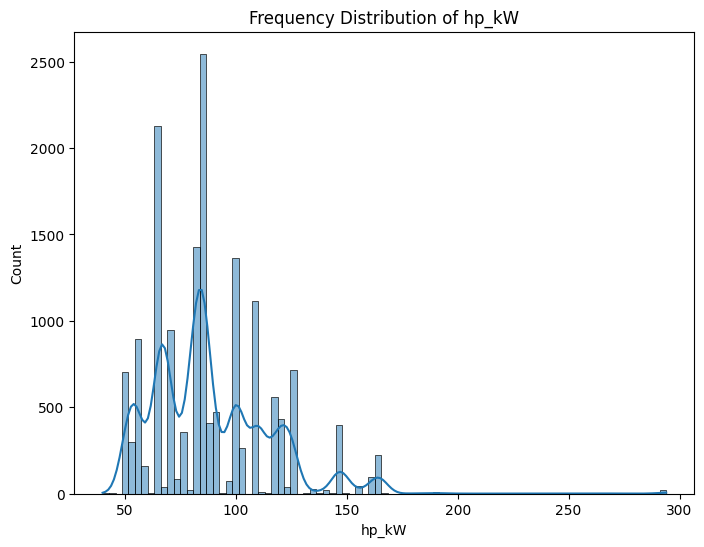

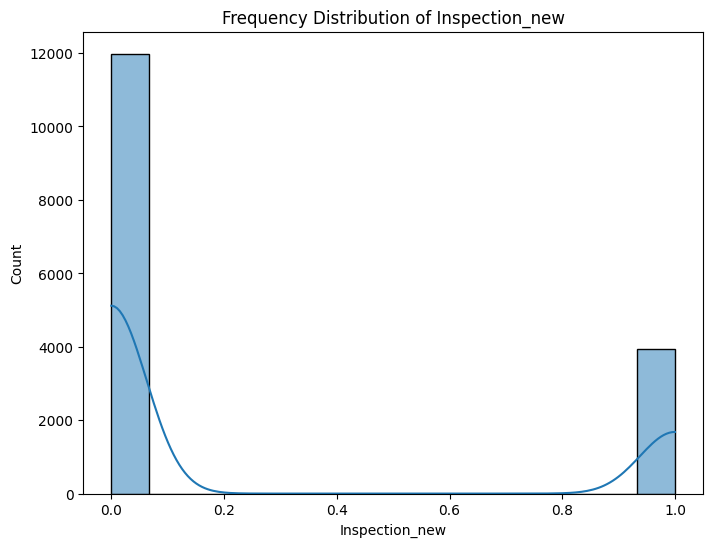

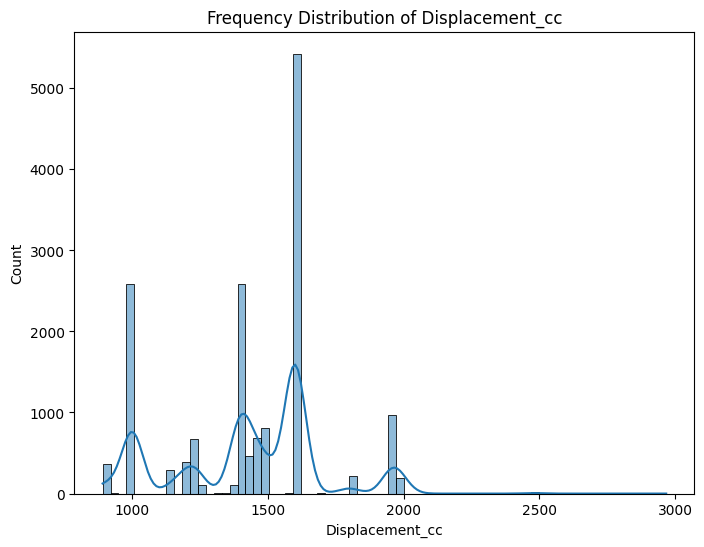

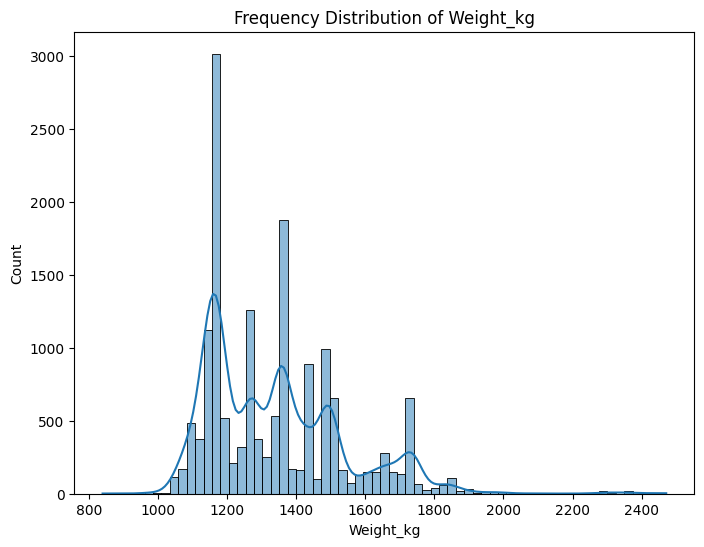

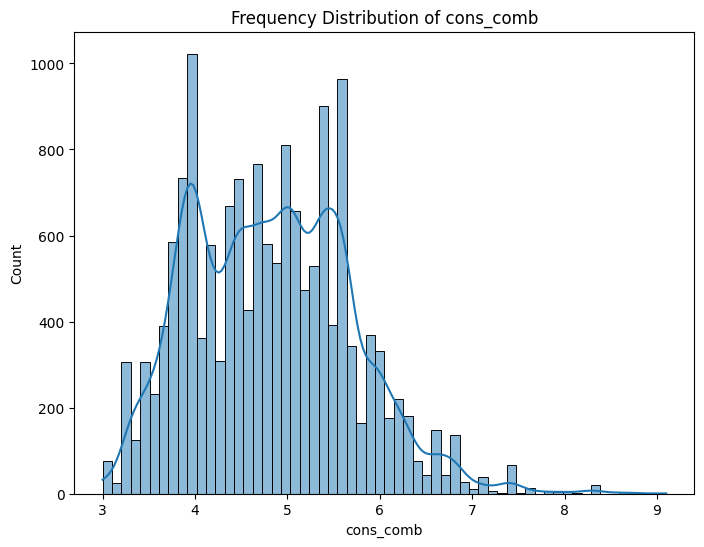

In [4]:
 # Identify numerical features and plot histograms
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
target_variable = 'price'
if target_variable in numerical_features:
  numerical_features.remove(target_variable)

print(f"Numerical Predictors Identified: {numerical_features}\n")
for feature in numerical_features:
  plt.figure(figsize=(8, 6))
  sns.histplot(df[feature], kde=True)
  plt.title(f'Frequency Distribution of {feature}')
  plt.xlabel(feature)

#### **2.1.3** <font color =red> [3 marks] </font>
Identify categorical predictors and plot their frequency distributions.

Categorical Predictors Identified: ['body_type', 'vat', 'Type', 'Fuel', 'Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain']

Error in callback <function _draw_all_if_interactive at 0x7f63fad12a20> (for post_execute):


KeyboardInterrupt: 

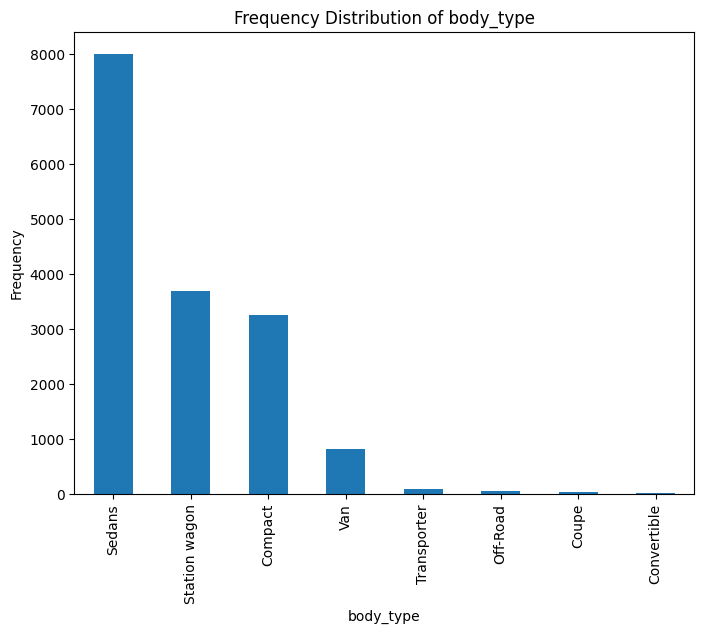

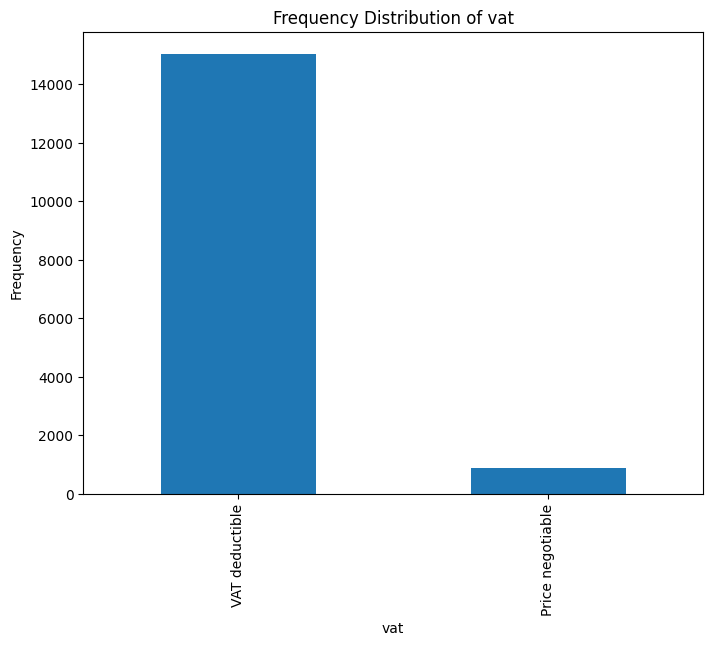

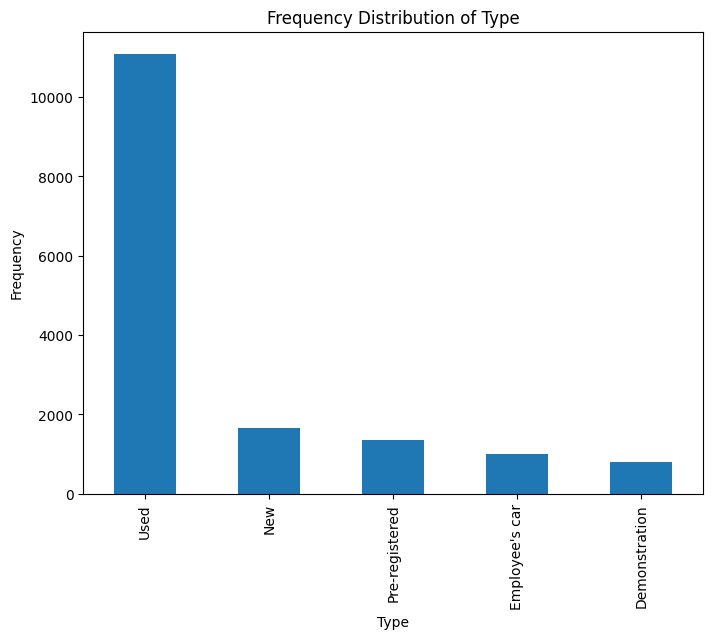

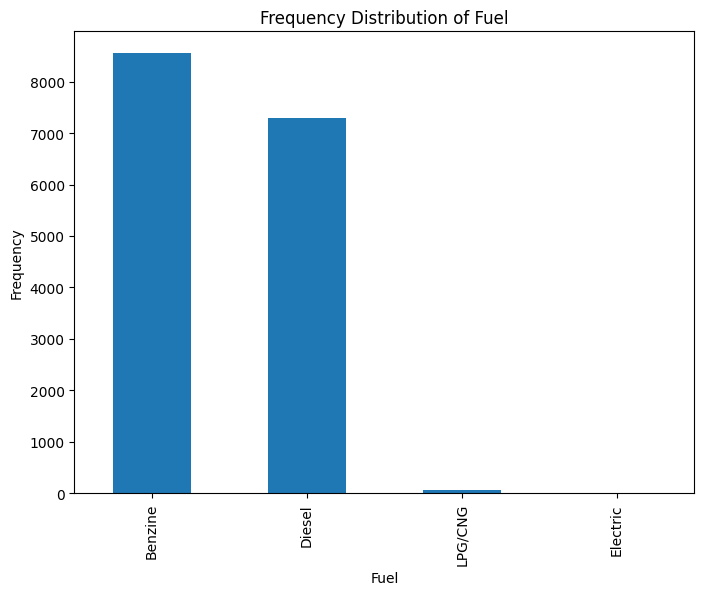

Error in callback <function flush_figures at 0x7f63fad07f60> (for post_execute):


KeyboardInterrupt: 

In [5]:
# Identify categorical columns and check their frequency distributions
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical Predictors Identified: {categorical_features}\n")
for feature in categorical_features:
  plt.figure(figsize=(8, 6))
  df[feature].value_counts().plot(kind='bar')
  plt.title(f'Frequency Distribution of {feature}')
  plt.xlabel(feature)
  plt.ylabel('Frequency')

**Note**: Look carefully at the values stored in columns `["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]`.

Should they be considered categorical? Should they be dropped or handled any other way?

#### **2.1.4** <font color =red> [3 marks] </font>
Fix columns with low frequency values and class imbalances.

Some information regarding values in the `Type` column that may help:
- *'Pre-registered'* cars are ones which have already been registered previously by the seller.
- *'New'* cars are not necessarily new cars, but new-like cars. These might also have multiple owners due to multiple pre-registrations as well.
- *'Employee's car'* are cars used by employees over a short period of time and small distance.
- *'Demonstration'* cars are used for trial purposes and also driven for a short time and distance.

Based on these, you can handle this particular column. For other columns, decide a strategy on your own.

In [6]:
# Fix columns as needed
threshold = 100
# Updated to match the actual case-sensitive column names
category_col = ['body_type', 'Type', 'Fuel', 'Paint_Type', 'Gearing_Type', 'Drive_chain']

for col in category_col:
  value_counts = df[col].value_counts()
  to_remove = value_counts[value_counts <= threshold].index
  for val in to_remove:
    df[col] = df[col].replace(val,'Other')

#### **2.1.5** <font color =red> [3 marks] </font>
Identify target variable and plot the frequency distributions. Apply necessary transformations.

Skewness of price before transformation: 1.24


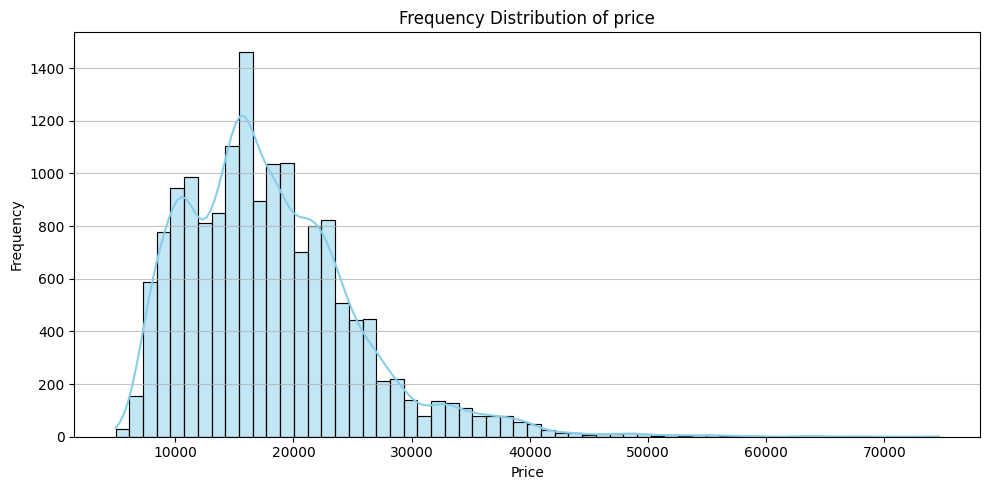

In [7]:
# Plot histograms for target feature
target_var ='price'

skewness_orig = df[target_var].skew()
print(f"Skewness of {target_var} before transformation: {skewness_orig:.2f}")

plt.figure(figsize=(10,5))
sns.histplot(df[target_var], bins=60, kde=True, color='skyblue')
plt.title(f'Frequency Distribution of {target_var}')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()

**The target variable seems to be skewed. Perform suitable transformation on the target.**

Skewness of price after transformation: -0.03


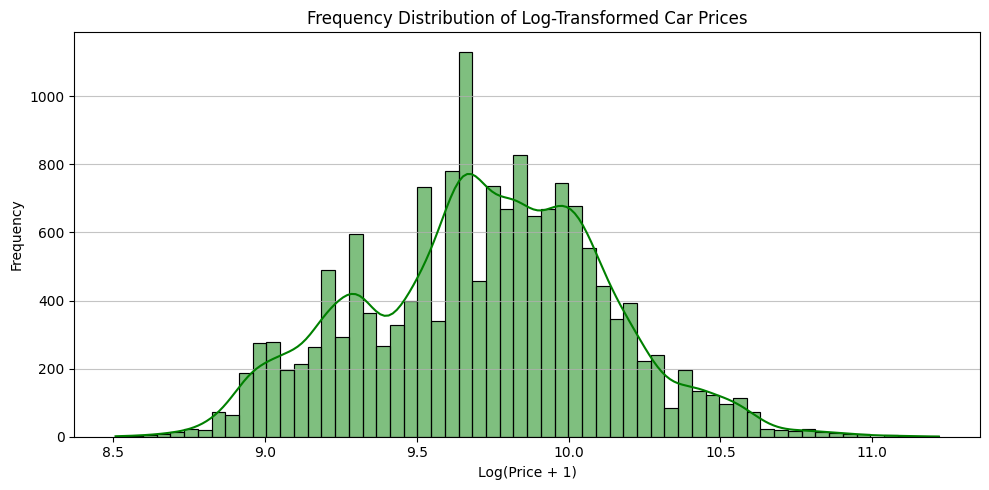

In [8]:
# Transform the target feature
df['log_price'] = np.log1p(df[target_var])
skewness_log = df['log_price'].skew()
print(f"Skewness of {target_var} after transformation: {skewness_log:.2f}")

plt.figure(figsize=(10, 5))
sns.histplot(df['log_price'], bins=60, kde=True, color='green')
plt.title('Frequency Distribution of Log-Transformed Car Prices')
plt.xlabel('Log(Price + 1)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()


### **2.2 Correlation analysis** <font color = red> [6 marks] </font>

#### **2.2.1** <font color =red> [3 marks] </font>
Plot the correlation map between features and target variable.

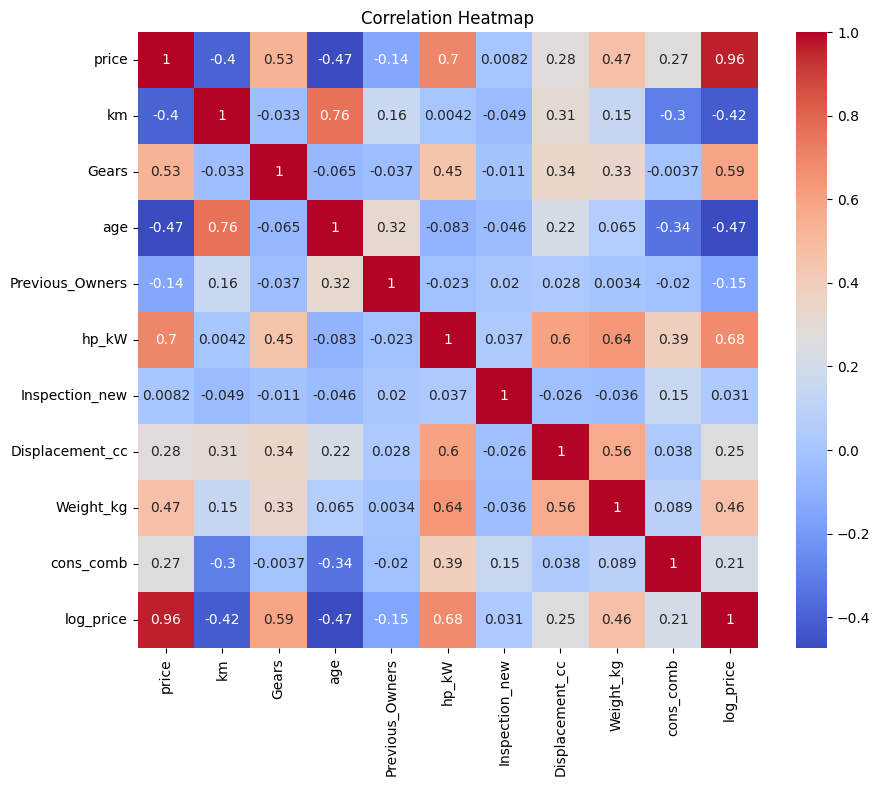

In [9]:
# Visualise correlation
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', ax=ax)
plt.title('Correlation Heatmap')
plt.show()


#### **2.2.2** <font color =red> [3 marks] </font>
Analyse correlation between categorical features and target variable.

Top 10 PositiveCategorical Correlations with Price:
body_type_Van                  0.402277
Gearing_Type_Automatic         0.391283
Type_New                       0.265968
Type_Demonstration             0.240910
Drive_chain_4WD                0.158032
Gearing_Type_Semi-automatic    0.123043
Type_Pre-registered            0.112766
Paint_Type_Metallic            0.045706
body_type_Station wagon        0.038460
Fuel_Diesel                    0.019079
Name: price, dtype: float64
Top 10 Negative Categorical Correlations with Price
Gearing_Type_Manual    -0.431675
Type_Used              -0.366384
body_type_Compact      -0.201934
Drive_chain_front      -0.155718
Paint_Type_Other       -0.049888
body_type_Sedans       -0.044334
Paint_Type_Uni/basic   -0.035390
Fuel_Benzine           -0.018197
body_type_Other        -0.014378
Fuel_Other             -0.006590
Name: price, dtype: float64


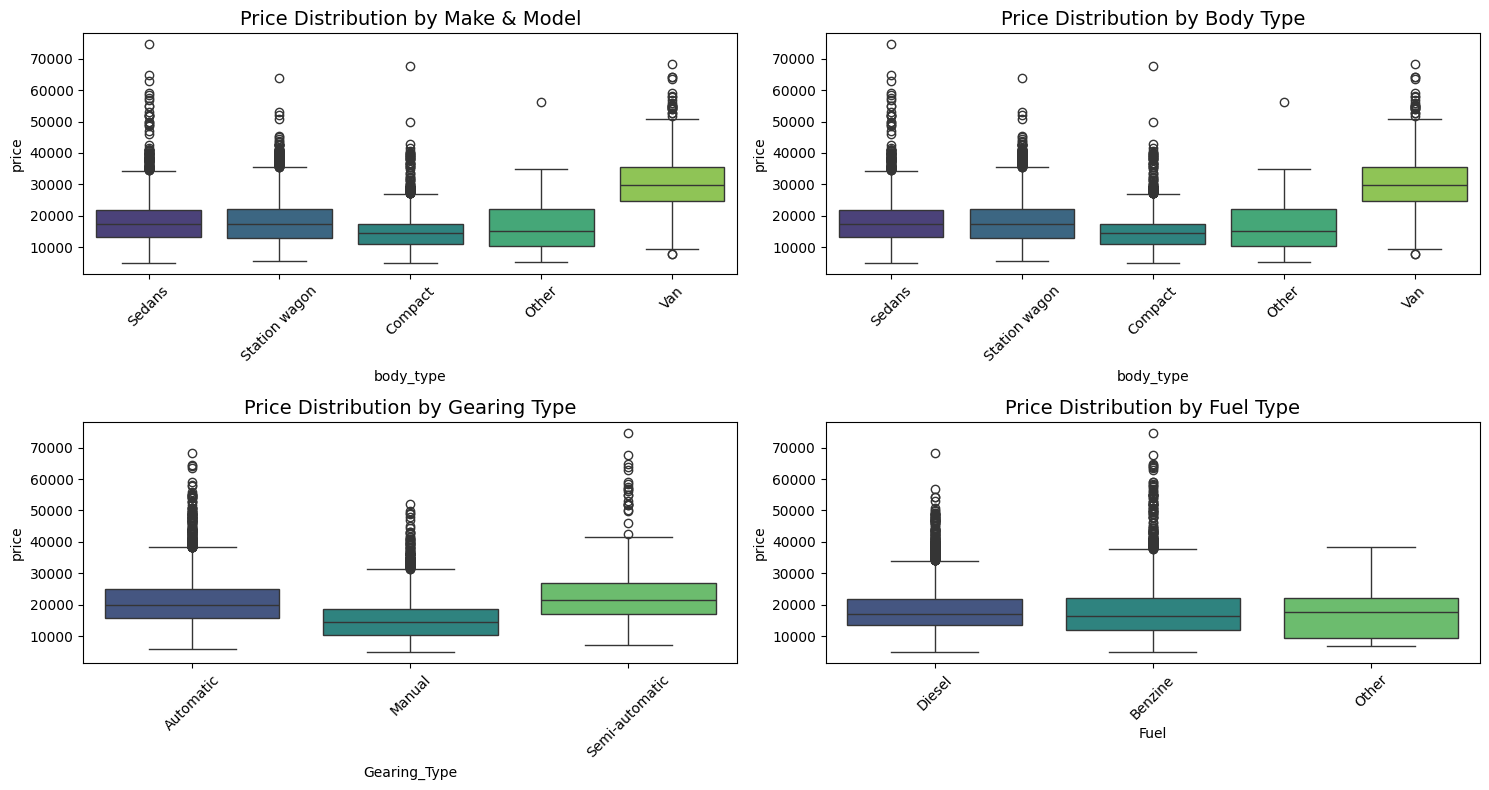

In [10]:
category_cols = ['body_type', 'Type', 'Fuel', 'Paint_Type', 'Gearing_Type', 'Drive_chain']

df_dummies = pd.get_dummies(df[category_cols], drop_first=False)
df_dummies['price']=df['price']

corr_with_price = df_dummies.corr()['price'].drop('price').sort_values(ascending=False)
print("Top 10 PositiveCategorical Correlations with Price:")
print(corr_with_price.head(10))
print("Top 10 Negative Categorical Correlations with Price")
print(corr_with_price.tail(10).sort_values(ascending=True))

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))

sns.boxplot(x='body_type', y='price', data=df, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Price Distribution by Make & Model', fontsize=14)
axes[0, 0].tick_params(axis='x', rotation=45)

sns.boxplot(x='body_type', y='price', data=df, ax=axes[0, 1], palette="viridis")
axes[0, 1].set_title('Price Distribution by Body Type', fontsize=14)
axes[0, 1].tick_params(axis='x', rotation=45)

sns.boxplot(x='Gearing_Type', y='price', data=df, ax=axes[1, 0], palette="viridis")
axes[1, 0].set_title('Price Distribution by Gearing Type', fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=45)

sns.boxplot(x='Fuel', y='price', data=df, ax=axes[1, 1], palette="viridis")
axes[1, 1].set_title('Price Distribution by Fuel Type', fontsize=14)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()

### **2.3 Outlier analysis** <font color = red> [5 marks] </font>

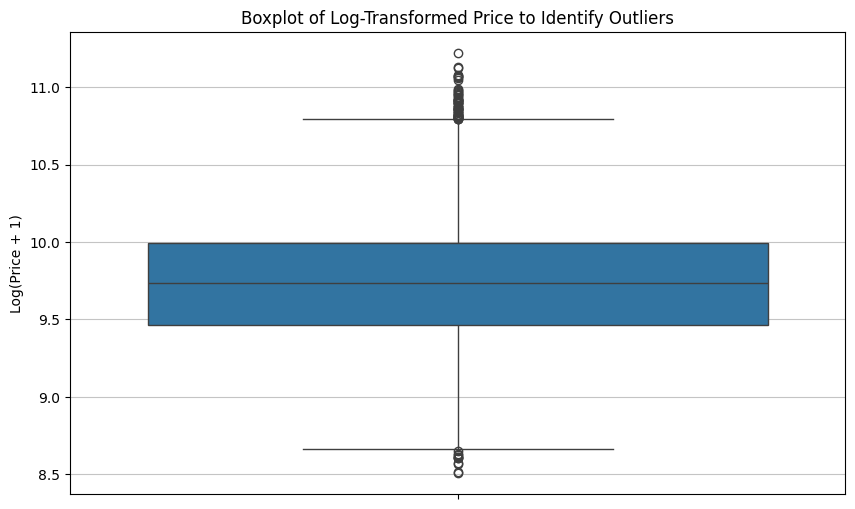

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['log_price'])
plt.title('Boxplot of Log-Transformed Price to Identify Outliers')
plt.ylabel('Log(Price + 1)')
plt.grid(axis='y', alpha=0.75)
plt.show()

#### **2.3.1** <font color =red> [2 marks] </font>
Identify potential outliers in the data.

In [12]:
# Outliers present in each column
num_cols = df.select_dtypes(include=[np.number]).columns

outlier_counts = {}
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers =df[(df[col]<lower_bound)|(df[col]>upper_bound)]
outlier_counts[col] = len(outliers)
print(outlier_counts)

{'log_price': 71}


#### **2.3.2** <font color =red> [3 marks] </font>
Handle the outliers suitably.

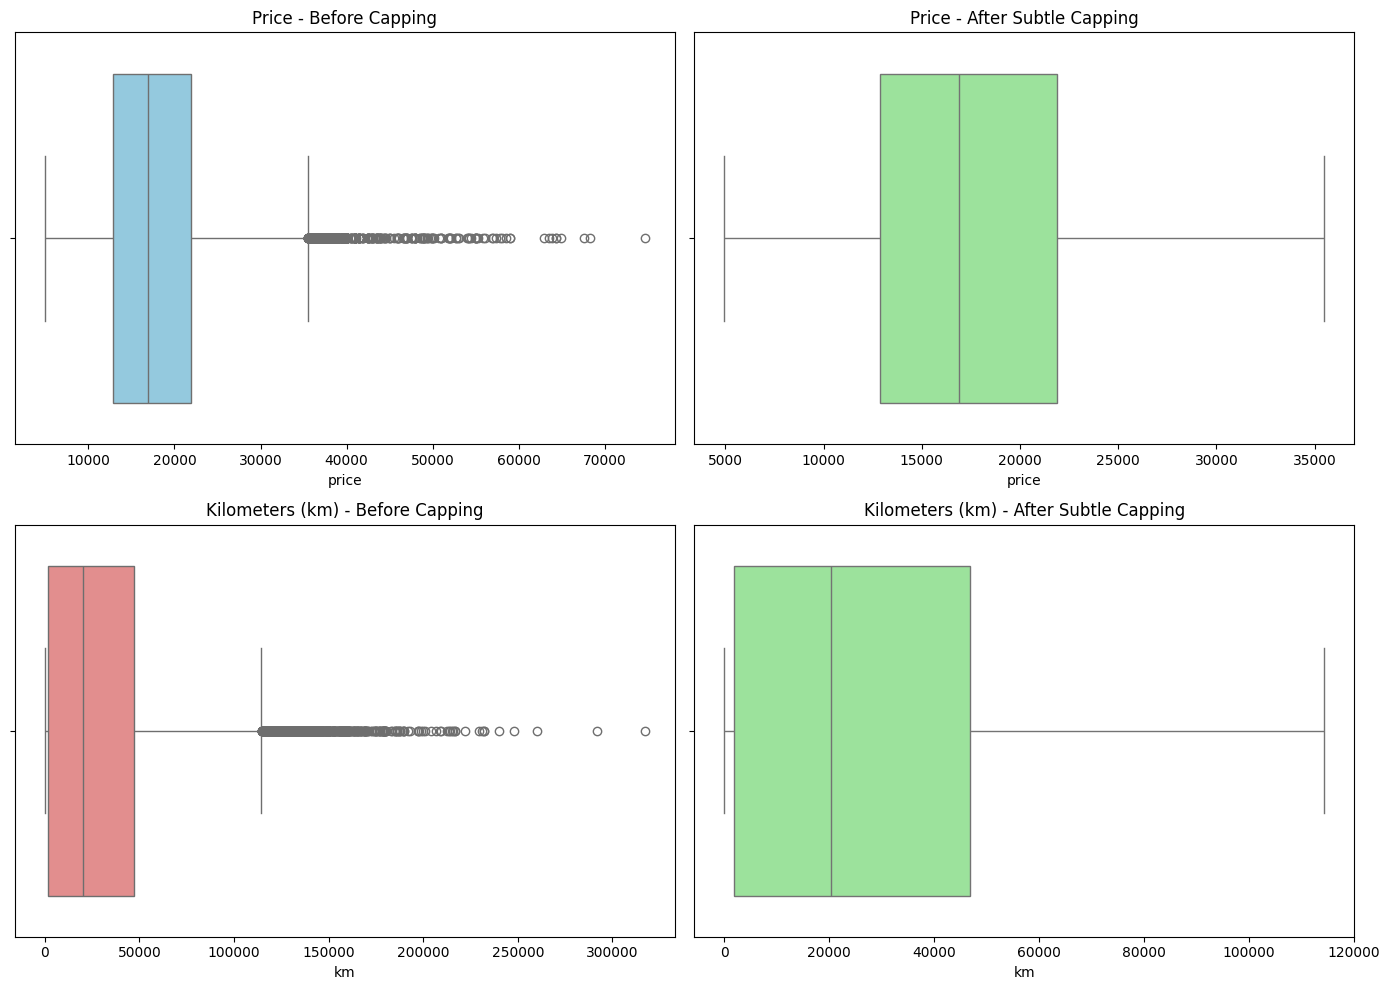

In [13]:
# Handle outliers
df_cleaned = df.copy()

cols_to_handle = ['price', 'km', 'hp_kW', 'Weight_kg', 'cons_comb', 'Displacement_cc']

for col in cols_to_handle:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_cleaned[col] = np.where(df_cleaned[col] > upper_bound, upper_bound, df_cleaned[col])
    df_cleaned[col] = np.where(df_cleaned[col] < lower_bound, lower_bound, df_cleaned[col])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x=df['price'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Price - Before Capping')

sns.boxplot(x=df_cleaned['price'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Price - After Subtle Capping')

sns.boxplot(x=df['km'], ax=axes[1, 0], color='lightcoral')
axes[1, 0].set_title('Kilometers (km) - Before Capping')

sns.boxplot(x=df_cleaned['km'], ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('Kilometers (km) - After Subtle Capping')

plt.tight_layout()
plt.savefig('outlier_handling.png')

df_cleaned.to_csv('Car_Price_data_cleaned.csv', index=False)

### **2.4 Feature Engineering** <font color = red> [11 marks] </font>

#### **2.4.1**
Fix any redundant columns and create new ones if needed.

In [14]:
# Fix/create columns as needed
list_cols = ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']

for col in list_cols:
  # Ensure the column exists and is of string type before applying .str methods
  if col in df.columns and df[col].dtype == 'object':
    df[col] = df[col].str.replace('[', '', regex=False).str.replace(']', '', regex=False).str.replace("'", '', regex=False)
    new_col_name = f'num_{col}'
    df[new_col_name] = df[col].fillna('').apply(lambda x: len(x.split(',')) if x != '' else 0)
    # Drop the original redundant text column
    df = df.drop(col, axis=1)
  else:
    print(f"Warning: Column '{col}' not found or not of object type. Skipping.")

# Inspect the new columns and dropped columns
print("New columns created:")
print(['make', 'model'] + [f'num_{col}' for col in list_cols])

print("\nFirst 5 rows of the new engineered features:")
print(df.reset_index()[['make_model', 'num_Comfort_Convenience', 'num_Entertainment_Media', 'num_Extras', 'num_Safety_Security']].head())

New columns created:
['make', 'model', 'num_Comfort_Convenience', 'num_Entertainment_Media', 'num_Extras', 'num_Safety_Security']

First 5 rows of the new engineered features:
  make_model  num_Comfort_Convenience  num_Entertainment_Media  num_Extras  \
0    Audi A1                       16                        4           3   
1    Audi A1                        9                        5           4   
2    Audi A1                       13                        2           2   
3    Audi A1                       16                        8           3   
4    Audi A1                       13                        7           4   

   num_Safety_Security  
0                   14  
1                   15  
2                   12  
3                   14  
4                   13  


#### **2.4.2** <font color =red> [4 marks] </font>
Analysis and feature engineering on `['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']`.

These columns contains lists of features present. Decide on how to include these features in the predictors.

In [15]:
# Check unique values in each feature spec column
list_cols = ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']

for col in list_cols:
  if col in df.columns:
    all_features = df[col].dropna().apply(lambda x: [item.strip() for item in x.split(',')])
    flat_list = [item for sublist in all_features for item in sublist]

    feature_counts = Counter(flat_list)

    print(f"\n--- {col} ---")
    print(f"Total Unique Features: {len(feature_counts)}")
    print("Top 10 Most Common Features:")
    for feature, count in feature_counts.most_common(10):
      print(f"  - {feature} ({count} cars)")

Out of these features, we will check the ones which are present in most of the cars or are absent from most of the cars. These kinds of features can be removed as they just increase the dimensionality without explaining the variance.

In [16]:
# Drop features from df

for col in list_cols:
  if col in df.columns:
    clean_col = df[col].fillna('').str.replace(',',', ')
    dummies= clean_col.str.get_dummies(sep=', ')

    if '' in dummies.columns:
      dummies = dummies.drop('', axis=1)
      all_features_df = pd.concat([all_features_df, dummies], axis=1)

      presence_pct = all_features_df.mean() * 100
      high_presence_features = presence_pct[presence_pct >= 90]
      low_presence_features = presence_pct[presence_pct <= 10]

      print(f"Total features extracted: {len(presence_pct)}")
      if len(high_presence_features) > 0:
        for feat, pct in high_presence_features.items():
          print(f"  - {feat} ({pct:.2f}%)")
      else:
        print("None")

        if len(low_presence_features) > 0:
          for feat, pct in low_presence_features.items():
            print(f"  - {feat} ({pct:.2f}%)")
        else:
          print("None")

#### **2.4.3** <font color =red> [3 marks] </font>
Perform feature encoding.

In [17]:
# Encode features



#### **2.4.4** <font color =red> [2 marks] </font>
Split the data into training and testing sets.

In [18]:
# Split data
X = df.drop(['price'], axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total dataset shape: {df.shape}")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

Total dataset shape: (15915, 23)
X_train shape: (12732, 22), y_train shape: (12732,)
X_test shape: (3183, 22), y_test shape: (3183,)


#### **2.4.5** <font color =red> [2 marks] </font>
Scale the features.

In [19]:
from sklearn.preprocessing import OneHotEncoder

# Read X_train and X_test from CSVs (as they were saved in the previous step)
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')

# Identify categorical and numerical columns
categorical_cols = X_train.select_dtypes(include='object').columns
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Initialize OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform categorical features for training data
X_train_encoded = ohe.fit_transform(X_train[categorical_cols])
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=ohe.get_feature_names_out(categorical_cols), index=X_train.index)

# Transform categorical features for testing data
X_test_encoded = ohe.transform(X_test[categorical_cols])
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=ohe.get_feature_names_out(categorical_cols), index=X_test.index)

# Concatenate encoded categorical features with numerical features
X_train_processed = pd.concat([X_train[numerical_cols], X_train_encoded_df], axis=1)
X_test_processed = pd.concat([X_test[numerical_cols], X_test_encoded_df], axis=1)

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the processed numerical features
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_processed), columns=X_train_processed.columns, index=X_train_processed.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_processed), columns=X_test_processed.columns, index=X_test_processed.index)

X_train_scaled.to_csv('X_train_scaled.csv', index=False)
X_test_scaled.to_csv('X_test_scaled.csv', index=False)

# Display the shapes and a small sample of the scaled features
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print("\nSample of scaled features (first 5 rows):")
# Adjust continuous_cols to include some of the original numerical columns if they exist
# Or just print a generic head if the exact columns might change after encoding
print(X_train_scaled.head())

X_train_scaled shape: (12732, 40)
X_test_scaled shape: (3183, 40)

Sample of scaled features (first 5 rows):
         km     Gears      age  Previous_Owners     hp_kW  Inspection_new  \
0 -0.699835 -1.333437 -1.24355        -0.127049 -1.225575       -0.574932   
1 -0.856764 -1.333437 -1.24355        -0.127049 -0.139815       -0.574932   
2  1.067171 -1.333437  1.43032        -0.127049 -0.551655       -0.574932   
3  0.448283 -1.333437  0.53903        -0.127049 -1.412776       -0.574932   
4 -0.867527  0.087140 -0.35226        -0.127049  2.855387       -0.574932   

   Displacement_cc  Weight_kg  cons_comb  log_price  ...  Paint_Type_Other  \
0        -1.926653  -1.104615   0.194489  -1.287884  ...         -0.041604   
1        -1.560687  -1.019218  -0.035569   0.694334  ...         -0.041604   
2        -0.114940   0.432521  -0.380657  -1.443165  ...         -0.041604   
3        -0.727299  -0.883589   0.539576  -1.608959  ...         -0.041604   
4         1.334430   1.984726   2.2650

## **3 Linear Regression Models** <font color =red> [35 marks] </font>


### **3.1 Baseline Linear Regression Model** <font color =red> [10 marks] </font>

#### **3.1.1** <font color =red> [5 marks] </font>
Build and fit a basic linear regression model. Perform evaluation using suitable metrics.

Mean Absolute Error (MAE): 1150.16
Root Mean Squared Error (RMSE): 1681.60
R-squared (R2): 0.9476


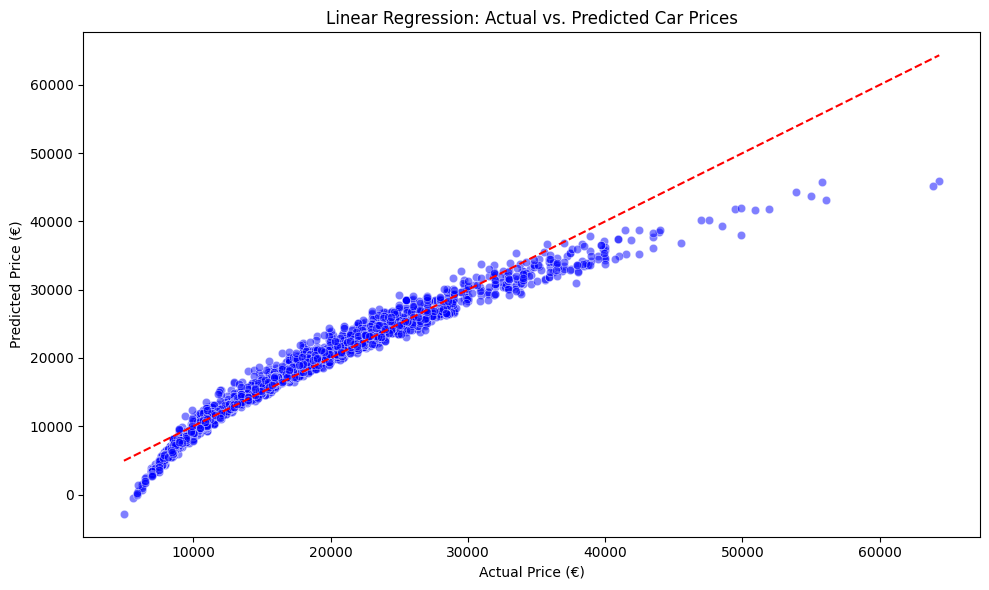

In [20]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = lr_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.4f}")

fig,ax = plt.subplots(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='blue', ax=ax)

ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
ax.set_xlabel('Actual Price (€)')
ax.set_ylabel('Predicted Price (€)')
ax.set_title('Linear Regression: Actual vs. Predicted Car Prices')
plt.tight_layout()

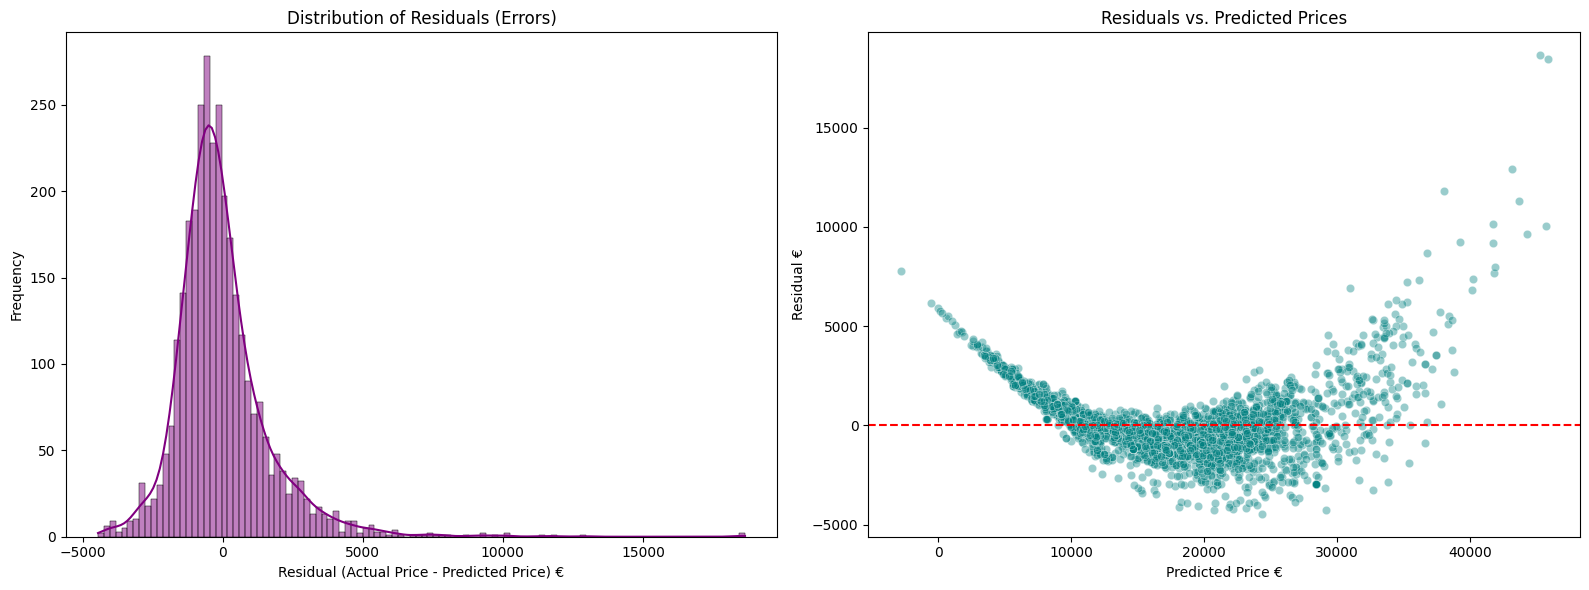

In [21]:
# Evaluate the model's performance
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)

residual = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(residual, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Distribution of Residuals (Errors)')
axes[0].set_xlabel('Residual (Actual Price - Predicted Price) €')
axes[0].set_ylabel('Frequency')

sns.scatterplot(x=y_pred, y=residual, alpha=0.4, ax=axes[1], color='teal')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residuals vs. Predicted Prices')
axes[1].set_xlabel('Predicted Price €')
axes[1].set_ylabel('Residual €')

plt.tight_layout()

In [22]:
print(list(X_train.columns))

['body_type', 'vat', 'km', 'Type', 'Fuel', 'Gears', 'age', 'Previous_Owners', 'hp_kW', 'Inspection_new', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Displacement_cc', 'Weight_kg', 'Drive_chain', 'cons_comb', 'log_price', 'num_Comfort_Convenience', 'num_Entertainment_Media', 'num_Extras', 'num_Safety_Security']


#### **3.1.2** <font color =red> [5 marks] </font>
Analyse residuals and check other assumptions of linear regression.

Check for linearity by analysing residuals vs predicted values

Text(0.5, 1.0, 'Linearity Check: Residuals vs. Predicted Values')

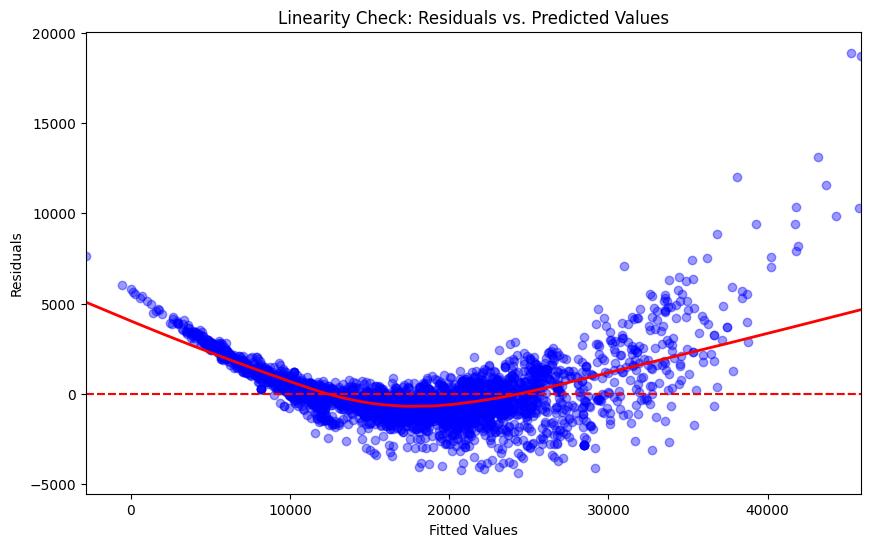

In [23]:
# Linearity check: Plot residuals vs fitted values
fig, ax = plt.subplots(figsize=(10, 6))

sns.residplot(x=y_pred, y=residual, lowess=True, line_kws={'color':'red', 'lw':2}, scatter_kws={'alpha':0.4, 'color':'blue'}, ax=ax)

ax.axhline(y=0, color='red', linestyle='--')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.set_title('Linearity Check: Residuals vs. Predicted Values')

Check normality in residual distribution

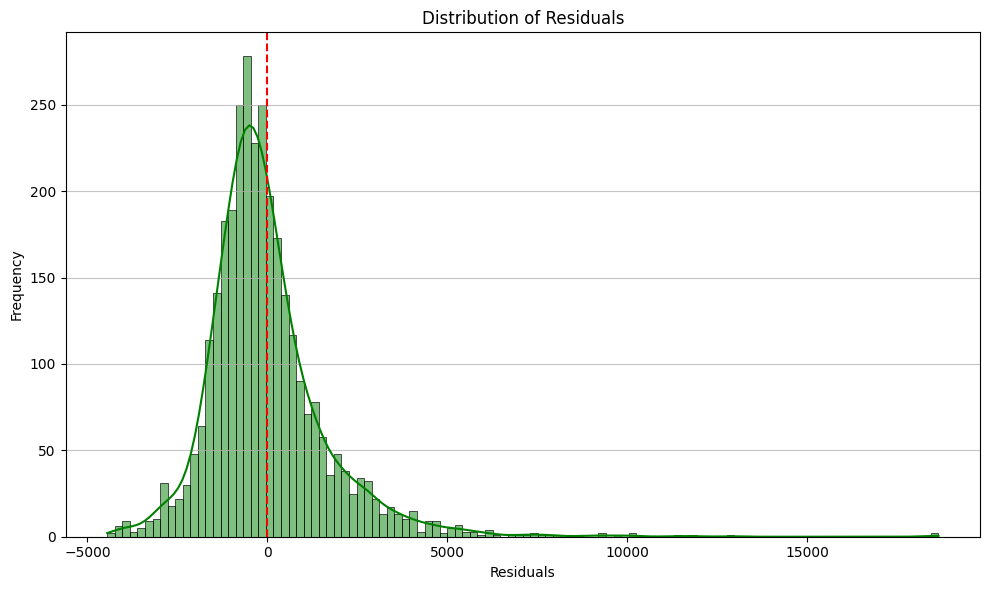

In [24]:
# Check the normality of residuals by plotting their distribution
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
residuals = y_test - y_pred

plt.figure(figsize=(10,6))
sns.histplot(residuals, kde=True, color='green')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()

Check multicollinearity using Variance Inflation Factor (VIF) and handle features with high VIF.

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use the scaled/encoded training data (must be numeric)
# We also exclude the target variable 'log_price' if it's in the feature set
X_vif_input = X_train_scaled.drop(columns=['log_price'], errors='ignore')

print(f"Starting with {X_vif_input.shape[1]} numeric features...\n")

features_to_keep = list(X_vif_input.columns)
dropped_features = []

while True:
    # Calculate VIF for current features
    vifs = [variance_inflation_factor(X_vif_input[features_to_keep].values, i) for i in range(len(features_to_keep))]

    max_vif = max(vifs)
    max_index = vifs.index(max_vif)
    max_feature = features_to_keep[max_index]

    if max_vif > 10:
        print(f"Dropping '{max_feature}' (VIF: {max_vif:.2f})")
        features_to_keep.pop(max_index)
        dropped_features.append(max_feature)
    else:
        break

print(f"\nDropped {len(dropped_features)} features due to high VIF.")
print(f"Final number of features remaining: {len(features_to_keep)}")

# Save the final datasets based on VIF selection
X_train_vif = X_train_scaled[features_to_keep]
X_test_vif = X_test_scaled[features_to_keep]

X_train_vif.to_csv('X_train_vif.csv', index=False)
X_test_vif.to_csv('X_test_vif.csv', index=False)

Starting with 39 numeric features...

Dropping 'body_type_Compact' (VIF: inf)
Dropping 'vat_Price negotiable' (VIF: inf)
Dropping 'Type_Demonstration' (VIF: inf)
Dropping 'Fuel_Benzine' (VIF: inf)
Dropping 'Paint_Type_Metallic' (VIF: inf)
Dropping 'Upholstery_type_Cloth' (VIF: inf)
Dropping 'Gearing_Type_Automatic' (VIF: inf)
Dropping 'Drive_chain_4WD' (VIF: inf)

Dropped 8 features due to high VIF.
Final number of features remaining: 31


### **3.2 Ridge Regression Implementation** <font color =red> [10 marks] </font>

#### **3.2.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [26]:
# List of alphas to tune for Ridge regularisation
alphas = np.logspace(-3, 3, 100)


#### **3.2.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [27]:
if 'price' in df.columns:
    # Select numeric features for simplicity
    numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('price')
    X = df[numeric_cols]
    y = df['price']

    # Handle missing values and scale data
    pipeline = Pipeline([
      ('imputer', SimpleImputer(strategy='median')),
      ('scaler', StandardScaler()),
      ('ridge', Ridge())
    ])

    # Define alphas to search
    alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
    param_grid = {'ridge__alpha': alphas}

    # Perform Grid Search with Cross-Validation, ensuring train scores are returned
    grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_absolute_error', return_train_score=True)
    grid_search.fit(X, y)

    best_alpha = grid_search.best_params_['ridge__alpha']
    best_score = grid_search.best_score_

    print(f"Alphas tested: {alphas}")
    print(f"Best Alpha: {best_alpha}")
    print(f"Best Mean Absolute Error: {best_score}")
else:
    print("Column 'price' not found in dataset.")

Alphas tested: [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
Best Alpha: 100.0
Best Mean Absolute Error: -1554.7975828053063


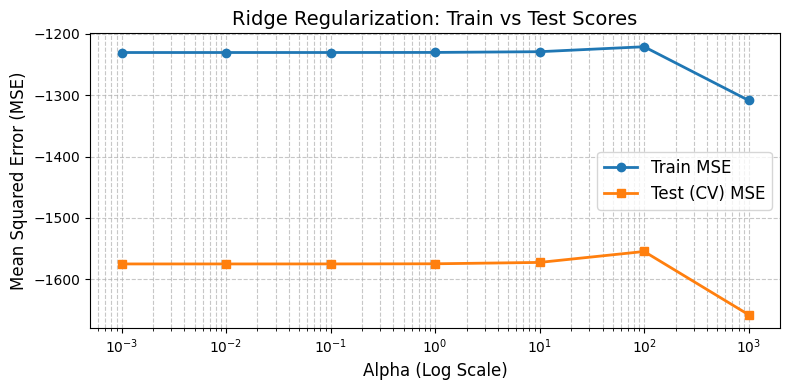

In [28]:
# Plot train and test scores against alpha
results=grid_search.cv_results_
train_scores= results['mean_train_score']
test_scores= results['mean_test_score']

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alphas, train_scores, label='Train MSE', marker='o', linewidth=2)
ax.plot(alphas, test_scores, label='Test (CV) MSE', marker='s', linewidth=2)

ax.set_xscale('log')
ax.set_xlabel('Alpha (Log Scale)', fontsize=12)
ax.set_ylabel('Mean Squared Error (MSE)', fontsize=12)
ax.set_title('Ridge Regularization: Train vs Test Scores', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which="both", ls="--", alpha=0.7)
plt.tight_layout()


Find the best alpha value.

In [29]:
# Best alpha value



# Best score (negative MAE)



We will get some best value of alpha above. This however is not the most accurate value but the best value from the given list. Now we have a rough estimate of the range that best alpha falls in. Let us do another iteration over the values in a smaller range.

#### **3.2.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [30]:
# Take a smaller range of alpha to test



In [31]:
# Applying Ridge regression



Plot the error-alpha graph again and find the actual optimal value for alpha.

In [32]:
# Plot train and test scores against alpha



# Best alpha value



# Best score (negative MAE)



In [33]:
# Set best alpha for Ridge regression
# Fit the Ridge model to get the coefficients of the fitted model
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
ridge = Ridge(alpha=best_alpha)

X_imputed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)
ridge.fit(X_scaled, y)


Ridge(alpha=100.0)

In [34]:
# Show the coefficients for each feature
coefficients = ridge.coef_
coef_df = pd.DataFrame({'Feature': numeric_cols, 'Coefficient': coefficients})

coef_df['Coefficient_Abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Coefficient_Abs', ascending=False).drop(columns=['Coefficient_Abs'])
coef_df.head(10)


,Feature,Coefficient
9,log_price,6918.192607
4,hp_kW,459.849398
8,cons_comb,411.586921
1,Gears,-333.808994
10,num_Comfort_Convenience,-313.619775
2,age,-304.987234
6,Displacement_cc,247.664011
12,num_Extras,-203.847480
0,km,201.079472
13,num_Safety_Security,198.462795


In [35]:
# Evaluate the Ridge model on the test data



### **3.3 Lasso Regression Implementation** <font color =red> [10 marks] </font>

#### **3.3.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [36]:
# List of alphas to tune for Lasso regularisation



#### **3.3.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [37]:
# Initialise Lasso regression model
df = pd.read_csv('Car_Price_data.csv')
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('price')
X = df[numeric_cols]
y = df['price']

# 2. Initialise the Pipeline and the Lasso Regression model
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    # Initialising Lasso. We bump up max_iter to ensure the optimization converges
    ('lasso', Lasso(max_iter=10000))
])

# 3. Define alphas to test
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
param_grid = {'lasso__alpha': alphas}

# 4. Perform Grid Search
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_absolute_error', return_train_score=True)
grid_search.fit(X, y)

print(f"Best Alpha: {grid_search.best_params_['lasso__alpha']}")
print(f"Best MAE: {grid_search.best_score_}")

Best Alpha: 0.001
Best MAE: -3394.8239747283233


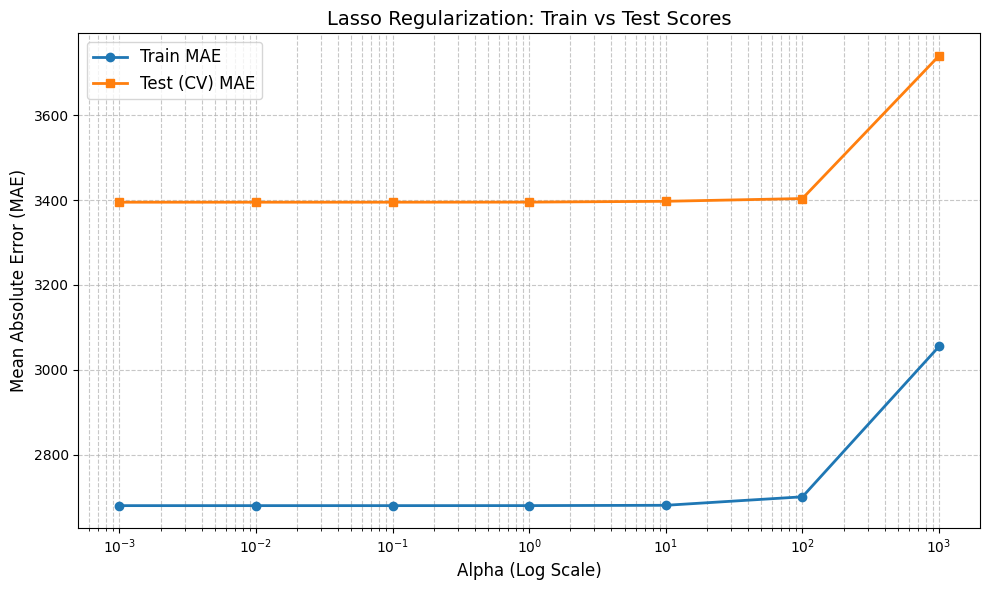

In [38]:
# Plot train and test scores against alpha
results = grid_search.cv_results_
train_scores = -results['mean_train_score']
test_scores = -results['mean_test_score']

# 7. Plotting the results
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(alphas, train_scores, label='Train MAE', marker='o', linewidth=2)
ax.plot(alphas, test_scores, label='Test (CV) MAE', marker='s', linewidth=2)

ax.set_xscale('log') # Log scale for better visibility
ax.set_xlabel('Alpha (Log Scale)', fontsize=12)
ax.set_ylabel('Mean Absolute Error (MAE)', fontsize=12)
ax.set_title('Lasso Regularization: Train vs Test Scores', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which="both", ls="--", alpha=0.7)

plt.tight_layout()


In [39]:
# Best alpha value


# Best score (negative MAE)



#### **3.3.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [40]:
# List of alphas to tune for Lasso regularization



In [41]:
# Tuning Lasso hyperparameters



In [42]:
# Plot train and test scores against alpha



In [43]:
# Best alpha value


# Best score (negative MAE)



In [44]:
# Set best alpha for Lasso regression


# Fit the Lasso model on scaled training data
# Get the coefficients of the fitted model
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('price')
X = df[numeric_cols]
y = df['price']

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

lasso = Lasso(alpha=0.001, max_iter=10000)
lasso.fit(X_scaled, y)

coefficients = lasso.coef_
coef_df = pd.DataFrame({
    'Feature': numeric_cols,
    'Coefficient': coefficients
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])

print(coef_df.to_string(index=False))

        Feature  Coefficient
          hp_kW  4405.920239
            age -2082.853547
          Gears  1670.142729
             km -1532.419412
      Weight_kg   908.986346
      cons_comb  -908.409511
Displacement_cc  -680.968963
 Inspection_new  -103.910121
Previous_Owners    -8.360998


In [45]:
# Check the coefficients for each feature



In [46]:
# Evaluate the Lasso model on the test data



### **3.4 Regularisation Comparison & Analysis** <font color =red> [5 marks] </font>

#### **3.4.1** <font color =red> [2 marks] </font>
Compare the evaluation metrics for each model.

In [47]:
from sklearn.model_selection import cross_validate

# Compare metrics for each model
ridge_pipe = Pipeline([('impuuter', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('ridge', Ridge(alpha=best_alpha))])
lasso_pipe = Pipeline([('impuuter', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('lasso', Lasso(alpha=0.001, max_iter=100000))])

scoring = {'MAE': 'neg_mean_absolute_error', 'MSE': 'neg_mean_squared_error', 'R2': 'r2'}

ridge_scores = cross_validate(ridge_pipe, X, y, cv=5, scoring=scoring)
lasso_scores = cross_validate(lasso_pipe, X, y, cv=5, scoring=scoring)

metrics = []
for name, scores in [('Ridge', ridge_scores), ('Lasso', lasso_scores)]:
  metrics.append({
      'Model': name,
      'MAE': -scores['test_MAE'].mean(),
      'MSE': -scores['test_MSE'].mean(),
      'R2': scores['test_R2'].mean()
  })

  results_df = pd.DataFrame(metrics)
  print(results_df)

   Model          MAE           MSE        R2
0  Ridge  3396.484975  1.972056e+07  0.524739
   Model          MAE           MSE        R2
0  Ridge  3396.484975  1.972056e+07  0.524739
1  Lasso  3394.823975  1.970916e+07  0.525298


In [48]:
import pickle

# Replace 'my_best_model' with the actual variable name of your trained model
# You can choose between lr_model, ridge, or lasso depending on which model you want to save.
with open('car_price_model.pkl', 'wb') as file:
    pickle.dump(lasso, file)

In [49]:
!pip install -q streamlit
!npm install localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 63.6 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧
added 22 packages in 3s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧

In [50]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle

st.set_page_config(layout="centered")
st.title("🚗 Vehicle Price Predictor")
st.write("Answer the questions below to get an estimated price for the vehicle.")

# Load the trained regression model
@st.cache_resource
def load_model():
    try:
        with open('car_price_model.pkl', 'rb') as file:
            return pickle.load(file)
    except FileNotFoundError:
        return None

model = load_model()

if model is None:
    st.error("Model file 'car_price_model.pkl' not found. Please upload it to Colab.")
    st.stop()

# Create the questionnaire using a form
with st.form("price_prediction_form"):
    st.subheader("Vehicle Specifications")

    # 1. Categorical Inputs (Update these options to match your dataset's exact encoding)
    make_model = st.selectbox("What is the make and model?", ['Audi A1', 'Audi A3', 'Opel Astra', 'Opel Corsa', 'Renault Clio'])
    gearing_type = st.radio("What is the transmission type?", ['Manual', 'Automatic', 'Semi-automatic'])

    # 2. Numerical Inputs (Ensure these align with any winsorization thresholds you set during training)
    age = st.number_input("What is the age of the car (in years)?", min_value=0, max_value=25, value=3)
    km = st.number_input("What is the total mileage (km)?", min_value=0, max_value=350000, value=50000, step=1000)
    hp = st.number_input("What is the horsepower (HP)?", min_value=40, max_value=400, value=100)

    submit_button = st.form_submit_button("Predict Price")

if submit_button:
    # 1. Create a DataFrame with the raw inputs
    input_df = pd.DataFrame({
        'make_model': [make_model],
        'gearing_type': [gearing_type],
        'age': [age],
        'km': [km],
        'hp': [hp]
    })

    # 2. Apply One-Hot Encoding
    input_encoded = pd.get_dummies(input_df)

    # 3. MANUALLY MAP YOUR COLUMNS HERE
    # Replace the list below with the exact output you copied from Step 1!
    expected_columns = [
        'age',
        'km',
        'hp',
        'make_model_Audi A3',
        'make_model_Opel Astra',
        'make_model_Opel Corsa',
        'make_model_Renault Clio',
        'gearing_type_Manual',
        'gearing_type_Semi-automatic'
    ]

    try:
        # 4. Align the columns with the model's expected columns
        input_final = input_encoded.reindex(columns=expected_columns, fill_value=0)

        # 5. Generate the prediction (convert input to numpy array to prevent warnings)
        prediction = model.predict(input_final.values)

        st.success(f"### Estimated Price: €{int(prediction[0]):,}")
        st.balloons()

    except Exception as e:
        st.error(f"Error making prediction: {e}")

Writing app.py


In [51]:
import urllib
print("Your LocalTunnel Password is:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n"))

Your LocalTunnel Password is: 35.224.56.12


In [52]:
!streamlit run app.py &>/content/logs.txt &

In [53]:
!pip install -q pyngrok

In [54]:
from pyngrok import ngrok

# Authenticate your ngrok account (replace with your token)
ngrok.set_auth_token("3I8XmnclOZ0JZbgQUTIPtz9cJcY_5G9KbArWLtfxoA1HVv7kU")

# Run Streamlit in the background
!streamlit run app.py &>/content/logs.txt &

# Open the tunnel
public_url = ngrok.connect(8501)
print(f"Your app is live at: {public_url.public_url}")

Your app is live at: https://overcast-reclaim-skittle.ngrok-free.dev


#### **3.4.2** <font color =red> [3 marks] </font>
Compare the coefficients for the three models.

Also visualise a few of the largest coefficients and the coefficients of features dropped by Lasso.

In [55]:
# Compare highest coefficients and coefficients of eliminated features



## **4 Conclusion & Key Takeaways**  <font color =red> [10 marks] </font>

What did you notice by performing regularisation? Did the model performance improve? If not, then why? Did you find overfitting or not? Was the data sufficent? Is a linear model sufficient?

#### **4.1 Conclude with outcomes and insights gained** <font color =red> [10 marks] </font>